# Chemistry Application

We consider the problem of densoising the Ramachandran plot of a given protein, which consists of noisy measurements of pairs of adjacent dihedral angles along the backbone of the protein. We consider the protein 6X8J and use publicly-available data from the Protein Data Bank (PDB).

Processing 6x8j.pdb1...
    sigma2 = 0.2610


Folds: 100%|██████████| 100/100 [00:03<00:00, 27.35it/s]


    optimal M = 3, optimal rho = 0.0769
Processing 1ADO.pdb1...
    sigma2 = 0.1479


Folds: 100%|██████████| 100/100 [00:20<00:00,  4.77it/s]


    optimal M = 4, optimal rho = 0.0806
Processing 1ENO.pdb1...
    sigma2 = 0.1228


Folds: 100%|██████████| 100/100 [00:02<00:00, 33.90it/s]


    optimal M = 2, optimal rho = 0.0726


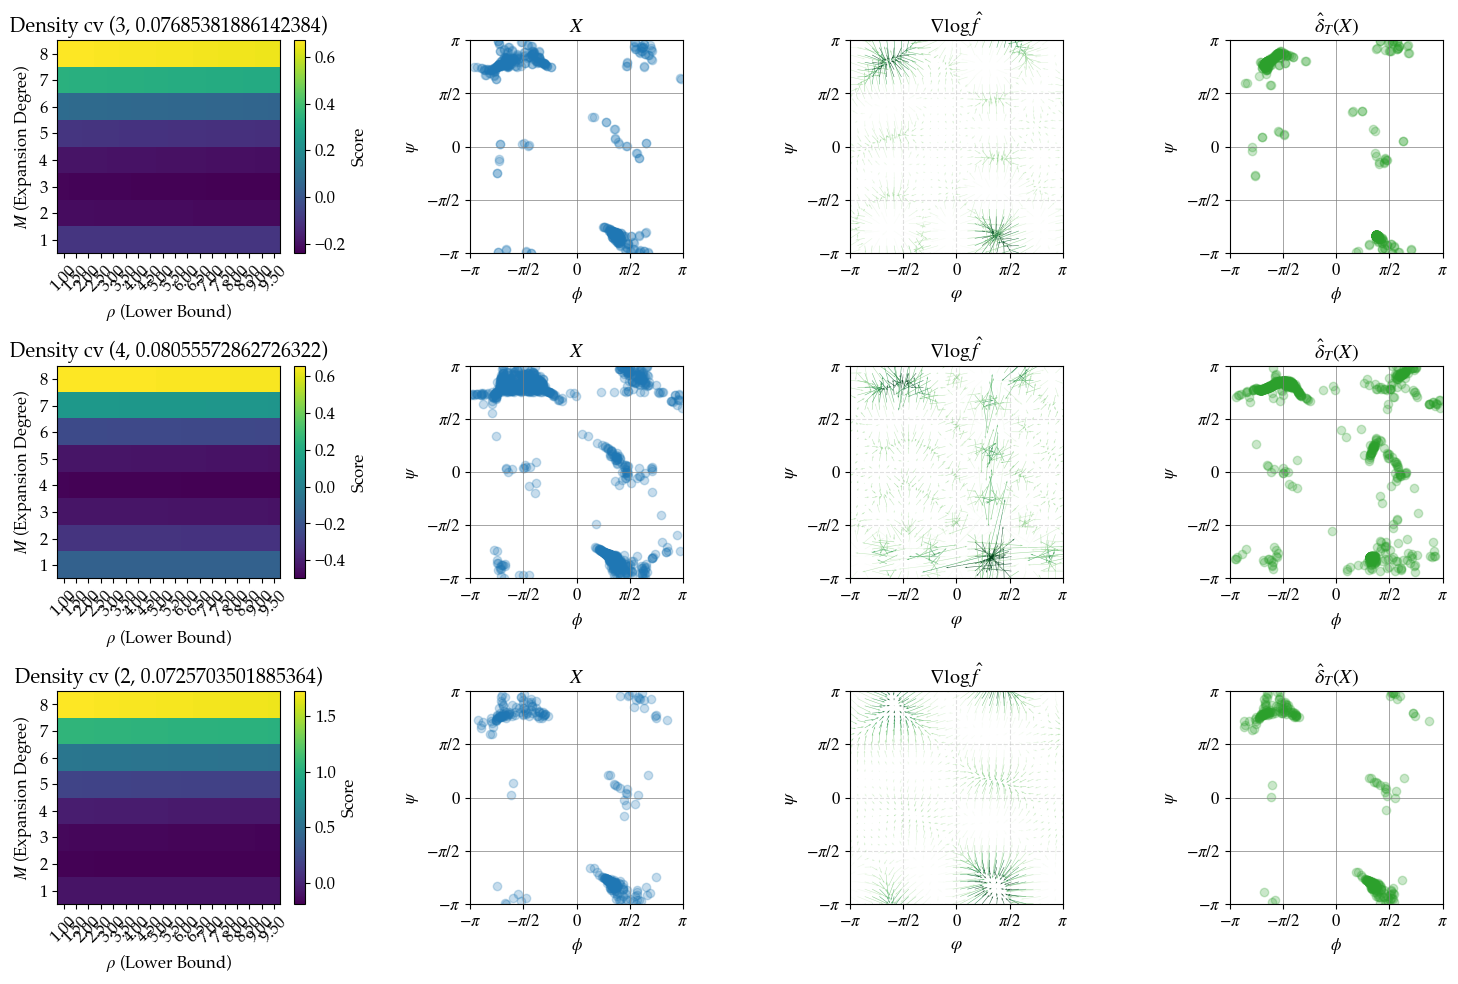

In [1]:
import sys, os
sys.path.append(os.getcwd().split('src')[0] + 'src')
from utils import *
manifold_type = 'T2'
import Bio.PDB
from Bio.PDB.vectors import calc_dihedral, calc_angle
from Bio import BiopythonWarning
import warnings
warnings.simplefilter('ignore', BiopythonWarning)

fig, aaxs = plt.subplots(3, 4, figsize=(15, 10))
for idx, file in enumerate(['6x8j.pdb1', '1ADO.pdb1', '1ENO.pdb1']):
    print(f"\nProcessing {file}...")
    # Parse the PDB file and extract the phi and psi angles
    parser = Bio.PDB.PDBParser()
    file = 'data/'+ file
    structure = parser.get_structure('protein', file)
    polypeptide = Bio.PDB.PPBuilder().build_peptides(structure[0])

    phi = []
    psi = []
    for strand in polypeptide:
        phipsi = strand.get_phi_psi_list()
        for point in phipsi:
            try:
                phi_point = point[0] * 1.
                psi_point = point[1] * 1.
                phi.append(phi_point)
                psi.append(psi_point)
            except TypeError:
                pass
        
    X_phi, X_psi = np.asarray(phi), np.asarray(psi)
    X = np.asarray([[np.cos(phi),np.sin(phi)],
                    [np.cos(psi),np.sin(psi)]]).T
    
    # Calculate the mean B-factor and the corresponding sigma2 for the T2 manifold
    mean_b_factor = 0.
    count = 0
    for model in structure:
        for chain in model:
            for residue in chain:
                for atom in residue:
                    count += 1
                    mean_b_factor += atom.get_bfactor()
    mean_b_factor /= count
    sigma2 = np.arctan(np.sqrt(mean_b_factor/(8*np.pi**2))/1.5)**2
    print(f'    sigma2 = {sigma2:.4f}')


    # Perform cross-validation to select the optimal parameters for density estimation
    M_grid=np.arange(1, 9)
    rhoperc_grid = np.arange(1,10,0.5)
    criterion = 'AIC'
    # params, scores = scoreMatchingKFoldCV(manifold_type, X, M_grid, rho_grid, n_splits=5, return_scores = True, random_state=42, rho_percentile = 1)
    params, scores = DensityKFoldCV(manifold_type, X, M_grid, rhoperc_grid, n_splits=100, return_scores = True, random_state=42)
    if True: plot_density_cv_scores(scores[criterion], M_grid, rhoperc_grid, title=f"Density cv {params[criterion]}", ax = aaxs[idx, 0])
    M, rho = params[criterion]
    print(f'    optimal M = {M}, optimal rho = {rho:.4f}')

    # Estimate the density using the optimal parameters
    res = 50   
    grid, grid_phi, grid_psi = T2grid(res)
    grid, hat_f, hat_grad_f = density_estimate(manifold_type, X, M, grid, sigma2)

    # denoiser
    delta = denoiser(manifold_type, X, M, rho, sigma2, X)

    # --------- plotting
    axs = aaxs[idx, 1:]

    # Top-left: X
    axs[0].grid(True, color="gray", lw=0.5)
    T2_scatter(X, ax=axs[0])
    axs[0].set_title(r"$X$")

    # right: denoised delta
    axs[2].grid(True, color="gray", lw=0.5)
    T2_scatter(delta, ax=axs[2], color = 'C2' )
    axs[2].set_title(r"$\hat{\delta}_T(X)$")

    # center: score field 
    _T2_grid = T2grid(30)[0]
    _T2_grid, _hat_f, _hat_grad_f = density_estimate(manifold_type, X, int(M), _T2_grid, sigma2)
    _score = _hat_grad_f / np.maximum(_hat_f[:, None, None], rho)
    vals_to_plot = {
        "gradient": {"vals": _hat_grad_f,"cmap": "Greys","title": r"$\nabla \hat f$",},
        "score": {"vals": _score,"cmap": "Greens","title": r"$\nabla \log \hat f$",
        },
    }
    WHICH = "score"  # "gradient" or "score"
    _lo, _hi = np.percentile(_hat_f, [5, 95])
    _hat_f = np.clip(_hat_f, _lo, _hi)
    T2plot_quiver(
        _T2_grid,
        vals_to_plot[WHICH]["vals"],
        figax=(fig, axs[1]),
        scale=5,
        skip=1,
        cmap=vals_to_plot[WHICH]["cmap"],
        cvals = _hat_f,
    )
    axs[1].set_title(vals_to_plot[WHICH]["title"])

    # axis formatting 
    for ax in axs.flatten():
        ax.set_xlim(-np.pi, np.pi)
        ax.set_ylim(-np.pi, np.pi)
        ax.set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
        ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
        ax.set_yticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
        ax.set_yticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
        ax.set_aspect("equal", adjustable="box")
os.makedirs("fig", exist_ok=True)
plt.savefig("fig/ramachandran_denoise.png", bbox_inches="tight")




In [ ]:
# fig, axs = plt.subplots(2, 2, figsize=(12, 12))

# # Top-left: X
# axs[0, 0].grid(True, color="gray", lw=0.5)
# axs[0, 0].set_title(r"$X$")
# T2_scatter(X, ax=axs[0, 0])

# # Top-right: denoised delta
# axs[0, 1].grid(True, color="gray", lw=0.5)
# axs[0, 1].set_title(r"$\hat{\delta}_T(X)$")
# T2_scatter(delta, ax=axs[0, 1], color = 'C2' )

# # Bottom-left: estimated density \hat f on the (phi, psi) grid
# axs[1, 0].set_title(r"$\hat f$")
# im_f = axs[1, 0].pcolormesh(
#     grid_phi, grid_psi,
#     hat_f.reshape(res, res),
#     shading="auto",
#     cmap="Blues",
#     alpha=0.85,
# )
# axs[1, 0].set_xlabel(r"$\varphi$")
# axs[1, 0].set_ylabel(r"$\psi$")
# axs[1, 0].set_aspect("equal")
# axs[1, 0].set_xlim(-np.pi, np.pi)
# axs[1, 0].set_ylim(-np.pi, np.pi)
# fig.colorbar(im_f, ax=axs[1, 0], orientation="horizontal", fraction=0.05, pad=0.14)

# # Bottom-right: gradient / score field (use the T2 quiver helper already defined)
# # _T2_grid = T2grid(40)[0]
# _T2_grid, _hat_f, _hat_grad_f = density_estimate(manifold_type, X, int(M), _T2_grid, sigma2)

# _score = _hat_grad_f / np.maximum(_hat_f[:, None, None], rho)

# vals_to_plot = {
#     "gradient": {"vals": _hat_grad_f,"cmap": "Blues","title": r"$\nabla \hat f$",},
#     "score": {"vals": _score,"cmap": "Greens","title": r"$\nabla \log \hat f$",
#     },
# }

# WHICH = "score"  # "gradient" or "score"

# T2plot_quiver(
#     _T2_grid,
#     vals_to_plot[WHICH]["vals"],
#     figax=(fig, axs[1, 1]),
#     scale=1,
#     skip=1,
#     cmap=vals_to_plot[WHICH]["cmap"],
# )
# axs[1, 1].set_title(vals_to_plot[WHICH]["title"])

# # Consistent axis formatting for the torus angle plots
# for ax in axs.flatten():
#     ax.set_xlim(-np.pi, np.pi)
#     ax.set_ylim(-np.pi, np.pi)
#     ax.set_xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
#     ax.set_xticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])
#     ax.set_yticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
#     ax.set_yticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])

# plt.tight_layout()
# os.makedirs("fig", exist_ok=True)
# plt.savefig("fig/ramachandran_denoise.png", bbox_inches="tight")
# plt.show()
